# Импорты

In [106]:
# %pip install matplotlib
# %pip install pymatgen

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [108]:
import os
import re
import glob
import xml.etree.ElementTree as ET

from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.symmetry.bandstructure import HighSymmKpath

In [109]:
from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun

In [110]:
import warnings

In [111]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [112]:
pd.set_option('display.float_format', '{:.2e}'.format)

#### Вспомогательные функции

In [113]:
DATA_DIR = '.'

Ha_TO_eV = 27.211386
Bohr_TO_A = 0.529177

def flt(el, path, default=0.0):
    node = el.find(path)
    t = node.text.strip() if node is not None and node.text else None
    return float(t) if t else default

def cell_from_xml(struct_el):
    return np.array([
        [float(x) * Bohr_TO_A for x in struct_el.find(f'.//cell/a{i}').text.split()]
        for i in range(1, 4)
    ])

def atoms_from_xml(struct_el):
    return [{'name': a.get('name'), 'coords': [float(x) for x in a.text.split()]}
            for a in struct_el.findall('.//atomic_positions/atom')]

def cell_to_a(cell):
    return np.linalg.norm(cell[0])

def make_structure(cell, atoms):
    species = [a['name'] for a in atoms]
    coords = [np.array(a['coords']) * Bohr_TO_A for a in atoms]
    return Structure(lattice=cell.tolist(), species=species,
                     coords=coords, coords_are_cartesian=True)

def parse_pw_in(text):
    params = {}
    for line in text.split('\n'):
        line = line.strip()
        if '=' in line and not line.startswith('!') and not line.startswith('&'):
            key, val = line.split('=', 1)
            params[key.strip()] = val.strip().rstrip(',')
    return params

def parse_scf(pw_out_path):
    ethrs, energies = [], []
    with open(pw_out_path) as f:
        for line in f:
            if line.strip().startswith('!'):
                continue
            m_ethr = re.search(r'ethr\s*=\s*([\d.E+-]+)', line)
            if m_ethr:
                ethrs.append(float(m_ethr.group(1)))
            m_e = re.search(r'total energy\s*=\s*([\-\d.]+)\s*Ry', line)
            if m_e:
                energies.append(float(m_e.group(1)))
    return energies, ethrs

#### Импорт файлов расчетов

In [114]:
with open(f'{DATA_DIR}/Ni/Ni.pw.in') as f:
    Ni_pw_input_file = f.read()
with open(f'{DATA_DIR}/Al/Al.pw.in') as f:
    Al_pw_input_file = f.read()
with open(f'{DATA_DIR}/Ni3Al/Ni3Al.pw.in') as f:
    Ni3Al_pw_input_file = f.read()

Ni_data_file_schema_xml = ET.parse(f'{DATA_DIR}/Ni/result/data-file-schema.xml').getroot()
Al_data_file_schema_xml = ET.parse(f'{DATA_DIR}/Al/result/data-file-schema.xml').getroot()
Ni3Al_data_file_schema_xml = ET.parse(f'{DATA_DIR}/Ni3Al/result/data-file-schema.xml').getroot()

Ni_input_section = Ni_data_file_schema_xml.find('.//input')
Al_input_section = Al_data_file_schema_xml.find('.//input')
Ni3Al_input_section = Ni3Al_data_file_schema_xml.find('.//input')

Ni_output_section = Ni_data_file_schema_xml.find('.//output')
Al_output_section = Al_data_file_schema_xml.find('.//output')
Ni3Al_output_section = Ni3Al_data_file_schema_xml.find('.//output')

Ni_input_atomic_structure = Ni_input_section.find('.//atomic_structure')
Al_input_atomic_structure = Al_input_section.find('.//atomic_structure')
Ni3Al_input_atomic_structure = Ni3Al_input_section.find('.//atomic_structure')

Ni_total_energy_section = Ni_output_section.find('.//total_energy')
Al_total_energy_section = Al_output_section.find('.//total_energy')
Ni3Al_total_energy_section = Ni3Al_output_section.find('.//total_energy')

Ni_band_structure_section = Ni_output_section.find('.//band_structure')
Al_band_structure_section = Al_output_section.find('.//band_structure')
Ni3Al_band_structure_section = Ni3Al_output_section.find('.//band_structure')

Ni_magnetization_section = Ni_output_section.find('.//magnetization')
Al_magnetization_section = Al_output_section.find('.//magnetization')
Ni3Al_magnetization_section = Ni3Al_output_section.find('.//magnetization')

Ni_k_points_IBZ = Ni_input_section.find('.//k_points_IBZ/monkhorst_pack')
Al_k_points_IBZ = Al_input_section.find('.//k_points_IBZ/monkhorst_pack')
Ni3Al_k_points_IBZ = Ni3Al_input_section.find('.//k_points_IBZ/monkhorst_pack')

In [115]:
# run_03 VASP - для сравнения
Ni_03_Outcar = Outcar("../VASP_run_03/Ni/result/OUTCAR")
Al_03_Outcar = Outcar("../VASP_run_03/Al/result/OUTCAR")
Ni3Al_03_Outcar = Outcar("../VASP_run_03/Ni3Al/result/OUTCAR")

Ni_03_vasprun = Vasprun("../VASP_run_03/Ni/result/vasprun.xml")
Al_03_vasprun = Vasprun("../VASP_run_03/Al/result/vasprun.xml")
Ni3Al_03_vasprun = Vasprun("../VASP_run_03/Ni3Al/result/vasprun.xml")

Ni_03_start_structure = Structure.from_file("../VASP_run_03/Ni/POSCAR")
Al_03_start_structure = Structure.from_file("../VASP_run_03/Al/POSCAR")
Ni3Al_03_start_structure = Structure.from_file("../VASP_run_03/Ni3Al/POSCAR")

# Параметры расчёта

In [116]:
df_input = pd.DataFrame({
    'Ni': parse_pw_in(Ni_pw_input_file),
    'Al': parse_pw_in(Al_pw_input_file),
    'Ni3Al': parse_pw_in(Ni3Al_pw_input_file)
}).fillna('')

df_input

,Ni,Al,Ni3Al
calculation,'relax','relax','relax'
restart_mode,'from_scratch','from_scratch','from_scratch'
tstress,.true.,.true.,.true.
tprnfor,.true.,.true.,.true.
outdir,'./tmp_Ni','./tmp_Al','./tmp_Ni3Al'
prefix,'Ni','Al','Ni3Al'
pseudo_dir,'/content','/content','/content'
starting_magnetization(1),0.6,,0.0
ecutwfc,80,40,80
ecutrho,500,200,500


# Проверка сходимости электронного и ионного цикла

> Все три расчёта завершились штатно и сошлись. Стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) заданы в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии, поэтому релаксация потребовала минимум итераций.

## Электронный цикл

In [117]:
Ni_E, Ni_ethr = parse_scf(f'{DATA_DIR}/Ni/result/Ni.pw.out')
Al_E, Al_ethr = parse_scf(f'{DATA_DIR}/Al/result/Al.pw.out')
Ni3Al_E, Ni3Al_ethr = parse_scf(f'{DATA_DIR}/Ni3Al/result/Ni3Al.pw.out')

In [118]:
data = []
max_len = max(len(Ni_ethr), len(Al_ethr), len(Ni3Al_ethr))
for i in range(max_len):
    row = {'Итерация': i + 1}
    if i < len(Ni_ethr):
        row['Ni ethr (Ry)'] = Ni_ethr[i]
    if i < len(Al_ethr):
        row['Al ethr (Ry)'] = Al_ethr[i]
    if i < len(Ni3Al_ethr):
        row['Ni3Al ethr (Ry)'] = Ni3Al_ethr[i]
    data.append(row)

df_delta_e = pd.DataFrame(data)
df_delta_e.style.hide(axis='index').format({
    col: '{:.10f}' for col in df_delta_e.columns if 'ethr' in col
})

Итерация,Ni ethr (Ry),Al ethr (Ry),Ni3Al ethr (Ry)
1,0.0100000000,0.0100000000,0.0100000000
2,0.0100000000,0.0001800000,0.0003320000
3,0.0044100000,0.0001790000,0.0003350000
4,0.0005330000,0.0000465000,0.0002050000
5,0.0000959000,0.0000001360,0.0000143000
6,0.0000751000,0.0000000014,0.0000003450
7,0.0000012300,0.0000000002,0.0000000852
8,0.0000000238,nan,0.0000000115
9,0.0000000066,nan,0.0000000115
10,0.0000000009,nan,0.0000000003


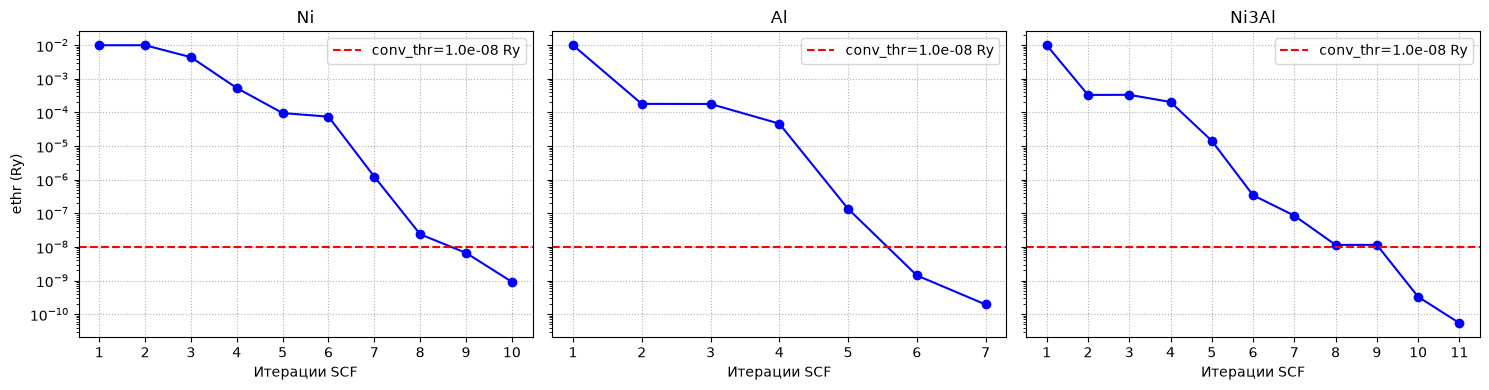

In [148]:
conv_thr_ry = flt(Ni_input_section, './/electron_control/conv_thr') * 2

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, ethr_data, name in zip(axes, [Ni_ethr, Al_ethr, Ni3Al_ethr], ['Ni', 'Al', 'Ni3Al']):
    ax.plot(range(1, len(ethr_data) + 1), ethr_data, 'o-', color='b')
    ax.axhline(conv_thr_ry, color='r', linestyle='--', label=f'conv_thr={conv_thr_ry:.1e} Ry')
    ax.set_yscale('log')    
    ax.set_xlabel('Итерации SCF')
    ax.set_title(name)
    ax.grid(linestyle=':')
    ax.legend()
    max_iter = len(ethr_data)
    ax.set_xticks(range(1, max_iter + 1))

axes[0].set_ylabel('ethr (Ry)')
plt.tight_layout()
plt.show()

## Ионный цикл

In [120]:
data_ion_forces = []
for name, xml in [('Ni', Ni_data_file_schema_xml), ('Al', Al_data_file_schema_xml), ('Ni3Al', Ni3Al_data_file_schema_xml)]:
    n_atoms = len(xml.findall('.//output/atomic_structure/atomic_positions/atom'))
    for i, step in enumerate(xml.findall('.//step')):
        forces = step.find('.//forces')
        f_max = np.max(np.abs(np.array([float(x) for x in forces.text.split()][:3*n_atoms]).reshape(n_atoms, 3))) * Ha_TO_eV / Bohr_TO_A if forces is not None else 0.0
        data_ion_forces.append({'Система': name, 'Ионный шаг': i, '|F_max| (эВ/Å)': f_max})

df_ion_forces = pd.DataFrame(data_ion_forces)
df_ion_forces

,Система,Ионный шаг,|F_max| (эВ/Å)
0,Ni,0,0.00e+00
1,Al,0,0.00e+00
2,Ni3Al,0,0.00e+00


> **Примечание по ионной сходимости**     
> Стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) заданы в позициях высокой симметрии, где силы обязаны быть нулевыми по симметрии. Расчёт сошёлся без движения ионов.

# Кристаллографические параметры

In [121]:
Ni_cell_initial = cell_from_xml(Ni_input_atomic_structure)
Al_cell_initial = cell_from_xml(Al_input_atomic_structure)
Ni3Al_cell_initial = cell_from_xml(Ni3Al_input_atomic_structure)

# Начальный параметр решетки
Ni_a = cell_to_a(Ni_cell_initial)
Al_a = cell_to_a(Al_cell_initial)
Ni3Al_a = cell_to_a(Ni3Al_cell_initial)

# Начальный объем
Ni_volume = make_structure(Ni_cell_initial, atoms_from_xml(Ni_input_atomic_structure)).volume
Al_volume = make_structure(Al_cell_initial, atoms_from_xml(Al_input_atomic_structure)).volume
Ni3Al_volume = make_structure(Ni3Al_cell_initial, atoms_from_xml(Ni3Al_input_atomic_structure)).volume

# Пространственная группа (по начальной структуре)
Ni_Space_Group = SpacegroupAnalyzer(make_structure(Ni_cell_initial, atoms_from_xml(Ni_input_atomic_structure)), 0.1).get_space_group_symbol()
Al_Space_Group = SpacegroupAnalyzer(make_structure(Al_cell_initial, atoms_from_xml(Al_input_atomic_structure)), 0.1).get_space_group_symbol()
Ni3Al_Space_Group = SpacegroupAnalyzer(make_structure(Ni3Al_cell_initial, atoms_from_xml(Ni3Al_input_atomic_structure)), 0.1).get_space_group_symbol()

In [122]:
# Параметры решётки из run_03 VASP
Ni_a_03 = Ni_03_start_structure.lattice.a
Al_a_03 = Al_03_start_structure.lattice.a
Ni3Al_a_03 = Ni3Al_03_start_structure.lattice.a

# Объем из run_03 VASP
Ni_volume_03 = Ni_03_start_structure.volume
Al_volume_03 = Al_03_start_structure.volume
Ni3Al_volume_03 = Ni3Al_03_start_structure.volume

In [123]:
pd.set_option('display.float_format', '{:.6f}'.format)

data_crystal = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Группа': [Ni_Space_Group, Al_Space_Group, Ni3Al_Space_Group],
    'a старт. QE (Å)': [Ni_a, Al_a, Ni3Al_a],
    'a старт. VASP (Å)': [Ni_a_03, Al_a_03, Ni3Al_a_03],
    'V старт. QE (Å³)': [Ni_volume, Al_volume, Ni3Al_volume],
    'V старт. VASP (Å³)': [Ni_volume_03, Al_volume_03, Ni3Al_volume_03],
}

df_crystal = pd.DataFrame(data_crystal)
df_crystal

,Система,Группа,a старт. QE (Å),a старт. VASP (Å),V старт. QE (Å³),V старт. VASP (Å³)
0,Ni,Fm-3m,3.519999,3.520000,43.614156,43.614208
1,Al,Fm-3m,4.049998,4.050000,66.430046,66.430125
2,Ni3Al,Pm-3m,3.569999,3.570000,45.499239,45.499293


> **Примечание о сравнении с run_03**                  
> Сравнение с результатами каталога `run_03` выполнено для верификации расчётов. В `run_03` использовался код VASP с параметром `ISIF = 2`, что означает релаксацию только ионных позиций при фиксированных параметрах элементарной ячейки (объём и форма остаются неизменными). В представленных расчётах Quantum ESPRESSO используется режим `calculation = 'relax'` (не `vc-relax` который соответствует `ISIF=3`), который также выполняет релаксацию исключительно атомных координат, без изменения решётки. Параметр `cell_dynamics = 'bfgs'` в данном случае задаёт алгоритм оптимизации ионных позиций, но не влияет на ячейку.  

# Магнитный момент

In [124]:
Al_total_mag = flt(Al_magnetization_section, 'total') if Al_magnetization_section is not None else 0.0
Al_total_mag

0.0

In [125]:
Ni_total_mag = flt(Ni_magnetization_section, 'total') if Ni_magnetization_section is not None else 0.0
print("Ni:", Ni_total_mag, "μ_B")

Ni: 2.468327120464196 μ_B



**из входного файла для Ni:**
```
nspin = 2
starting_magnetization(1) = 0.6
```

Получив для чистого никеля `total_mag = 2.468 µ_B` (при стартовом `starting_magnetization = 0.6 µ_B`), можно заключить, что система не только сохранила заданную намагниченность, но и увеличила её за счёт обменного взаимодействия. Финальное значение близко к экспериментальному (∼0.6 µ_B на атом Ni), что подтверждает устойчивость ферромагнитного состояния в чистом Ni.

In [126]:
Ni3Al_total_mag = flt(Ni3Al_magnetization_section, 'total') if Ni3Al_magnetization_section is not None else 0.0
print("Ni3Al:", Ni3Al_total_mag, "μ_B")

Ni3Al: -0.0002161482820235134 μ_B


**из входного файла для Ni3Al:**
```
nspin = 2
starting_magnetization(1) = 0.0
starting_magnetization(2) = 0.0
```

Несмотря на то, что в входном файле был задан `nspin = 2`, итоговая суммарная намагниченность системы оказалась практически равной нулю (-0.00022 µ_B). Это свидетельствует о том, что спонтанная спиновая поляризация в данной структуре отсутствует – расчёт привёл к немагнитному состоянию.

Такое поведение согласуется с литературными данными для объёмного Ni₃Al со структурой L1₂ – он действительно является слабомагнитным или парамагнитным при комнатных условиях.

# Полные энергии и энтальпия образования Ni3Al

In [127]:
# Полные энергии
TOTEN_Ni = flt(Ni_total_energy_section, 'etot') * Ha_TO_eV
TOTEN_Al = flt(Al_total_energy_section, 'etot') * Ha_TO_eV
TOTEN_Ni3Al = flt(Ni3Al_total_energy_section, 'etot') * Ha_TO_eV

print("Ni:", TOTEN_Ni, "эВ")
print("Al:", TOTEN_Al, "эВ")
print("Ni3Al:", TOTEN_Ni3Al, "эВ")

Ni: -23355.9464029759 эВ
Al: -2149.8657535981547 эВ
Ni3Al: -18056.12528115997 эВ


In [128]:
# Изменение энтальпии образования, выраженное в электрон-вольтах на одну формульную единицу
dH_form_ev_per_fu = TOTEN_Ni3Al - (0.75*TOTEN_Ni + 0.25*TOTEN_Al)

# Изменение энтальпии образования, выраженное в килоджоулях на моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu * 96.485

# Изменение энтальпии образования, выраженное в килоджоулях на моль атомов
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.6990405285032466 эВ
-163.93192539263575 кДж/моль формульных единиц
-40.98298134815894 кДж/моль атомов


# K-точки

In [129]:
# K-cетка
Ni_kmesh = (int(Ni_k_points_IBZ.get('nk1')), int(Ni_k_points_IBZ.get('nk2')), int(Ni_k_points_IBZ.get('nk3'))) if Ni_k_points_IBZ is not None else None
Al_kmesh = (int(Al_k_points_IBZ.get('nk1')), int(Al_k_points_IBZ.get('nk2')), int(Al_k_points_IBZ.get('nk3'))) if Al_k_points_IBZ is not None else None
Ni3Al_kmesh = (int(Ni3Al_k_points_IBZ.get('nk1')), int(Ni3Al_k_points_IBZ.get('nk2')), int(Ni3Al_k_points_IBZ.get('nk3'))) if Ni3Al_k_points_IBZ is not None else None

# K-точки высокой симметрии
Ni_start_struct = make_structure(Ni_cell_initial, atoms_from_xml(Ni_input_atomic_structure))
Al_start_struct = make_structure(Al_cell_initial, atoms_from_xml(Al_input_atomic_structure))
Ni3Al_start_struct = make_structure(Ni3Al_cell_initial, atoms_from_xml(Ni3Al_input_atomic_structure))

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_Ni = SpacegroupAnalyzer(Ni_start_struct).get_primitive_standard_structure()
prim_Al = SpacegroupAnalyzer(Al_start_struct).get_primitive_standard_structure()
prim_Ni3Al = SpacegroupAnalyzer(Ni3Al_start_struct).get_primitive_standard_structure()

# K-точки высокой симметрии
Ni_hs_points = ', '.join(HighSymmKpath(prim_Ni).kpath['kpoints'].keys())
Al_hs_points = ', '.join(HighSymmKpath(prim_Al).kpath['kpoints'].keys())
Ni3Al_hs_points = ', '.join(HighSymmKpath(prim_Ni3Al).kpath['kpoints'].keys())

In [130]:
data_kpoints = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'K-сетка QE': [f'{Ni_kmesh[0]}×{Ni_kmesh[1]}×{Ni_kmesh[2]}',
              f'{Al_kmesh[0]}×{Al_kmesh[1]}×{Al_kmesh[2]}',
              f'{Ni3Al_kmesh[0]}×{Ni3Al_kmesh[1]}×{Ni3Al_kmesh[2]}'],
    'K-сетка VASP': ['18×18×18', '16×16×16', '18×18×18'],
    'Высокосимм. точки': [Ni_hs_points, Al_hs_points, Ni3Al_hs_points],
}

df_kpoints = pd.DataFrame(data_kpoints)
df_kpoints

,Система,K-сетка QE,K-сетка VASP,Высокосимм. точки
0,Ni,8×8×8,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,8×8×8,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,8×8×8,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [131]:
Ni_nelect = int(flt(Ni_band_structure_section, 'nelec')) if Ni_band_structure_section is not None else 0
Al_nelect = int(flt(Al_band_structure_section, 'nelec')) if Al_band_structure_section is not None else 0
Ni3Al_nelect = int(flt(Ni3Al_band_structure_section, 'nelec')) if Ni3Al_band_structure_section is not None else 0

# Кол-во электронов
print(f"Ni:  {Ni_nelect} электронов")
print(f"Al:  {Al_nelect} электронов")
print(f"Ni3Al: {Ni3Al_nelect} электронов")

Ni:  72 электронов
Al:  12 электронов
Ni3Al: 57 электронов


In [132]:
Ni_Fermi_energy = flt(Ni_band_structure_section, 'fermi_energy') * Ha_TO_eV if Ni_band_structure_section is not None else 0
Al_Fermi_energy = flt(Al_band_structure_section, 'fermi_energy') * Ha_TO_eV if Al_band_structure_section is not None else 0
Ni3Al_Fermi_energy = flt(Ni3Al_band_structure_section, 'fermi_energy') * Ha_TO_eV if Ni3Al_band_structure_section is not None else 0

Ni_total_DOS_data = np.loadtxt(f'{DATA_DIR}/Ni/result/Ni.pdos_tot')
Al_total_DOS_data = np.loadtxt(f'{DATA_DIR}/Al/result/Al.pdos_tot')
Ni3Al_total_DOS_data = np.loadtxt(f'{DATA_DIR}/Ni3Al/result/Ni3Al.pdos_tot')

# E (eV)  dosup(E)   dosdw(E)  pdosup(E)  pdosdw(E)

Ni_total_DOS_energy = Ni_total_DOS_data[:, 0]
Ni_total_DOS_density = Ni_total_DOS_data[:, 1] + Ni_total_DOS_data[:, 2] # dosup(E) + dosdw(E) <-- для использования обоих спиновых каналов

Al_total_DOS_energy = Al_total_DOS_data[:, 0]
Al_total_DOS_density = Al_total_DOS_data[:, 1]

Ni3Al_total_DOS_energy = Ni3Al_total_DOS_data[:, 0]
Ni3Al_total_DOS_density = Ni3Al_total_DOS_data[:, 1] + Ni3Al_total_DOS_data[:, 2]

In [133]:
# Энергии Ферми из VASP run_03
Ni_efermi_03 = Ni_03_Outcar.efermi
Al_efermi_03 = Al_03_Outcar.efermi
Ni3Al_efermi_03 = Ni3Al_03_Outcar.efermi

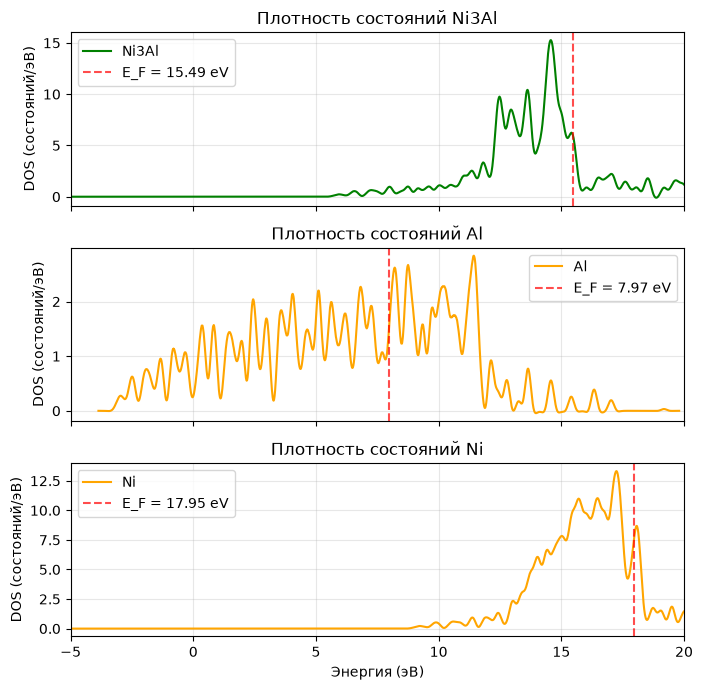

In [134]:
fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ni3Al
axes[0].plot(Ni3Al_total_DOS_energy, Ni3Al_total_DOS_density, color='green', label='Ni3Al')
axes[0].axvline(Ni3Al_Fermi_energy, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni3Al_Fermi_energy:.2f} eV')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Плотность состояний Ni3Al')

# Al
axes[1].plot(Al_total_DOS_energy, Al_total_DOS_density, color='orange', label='Al')
axes[1].axvline(Al_Fermi_energy, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Al_Fermi_energy:.2f} eV')
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Плотность состояний Al')

# Ni
axes[2].plot(Ni_total_DOS_energy, Ni_total_DOS_density, color='orange', label='Ni')
axes[2].axvline(Ni_Fermi_energy, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni_Fermi_energy:.2f} eV')
axes[2].set_xlabel('Энергия (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].legend()
axes[2].grid(alpha=0.3)
axes[2].set_title('Плотность состояний Ni')

plt.xlim(-5, 20)
plt.tight_layout()
plt.show()

## Проектированный DOS (projwfc.x)

In [135]:
def load_element_dos(system_dir, system_name):
    files = sorted(glob.glob(os.path.join(system_dir, f'{system_name}.pdos_atm#*')))
    element_files = {}
    for f in files:
        elem = re.search(r'atm#\d+\((\w+)\)', os.path.basename(f)).group(1)
        element_files.setdefault(elem, []).append(f)

    element_dos = {}
    for elem, elem_files in element_files.items():
        energy, up, dn = None, None, None
        for f in elem_files:
            data = np.loadtxt(f, skiprows=1)
            if energy is None:
                energy = data[:, 0]
                up = np.zeros_like(energy)
                dn = np.zeros_like(energy)
            n = data.shape[1]
            if n >= 5:   # spin-polarized: E, ldosup, ldosdn, pdosup, pdosdn
                up += data[:, 3]; dn += data[:, 4]
            elif n == 3: # non-spin-polarized: E, ldos, pdos
                up += data[:, 2]
        element_dos[elem] = {'energy': energy, 'up': up, 'dn': dn}
    return element_dos

In [136]:
Ni3Al_element_dos = load_element_dos(f'{DATA_DIR}/Ni3Al/result', 'Ni3Al')
Ni3Al_pdos_Al = Ni3Al_element_dos['Al']
Ni3Al_pdos_Ni = Ni3Al_element_dos['Ni']

# Раздельные спиновые каналы для тотального DOS (из pdos_tot: столбцы 1 и 2)
dens_up_total = Ni3Al_total_DOS_data[:, 1]
dens_down_total = Ni3Al_total_DOS_data[:, 2]

# PDOS каналы уже есть в словарях
dens_up_Al = Ni3Al_pdos_Al['up']
dens_down_Al = Ni3Al_pdos_Al['dn']
dens_up_Ni = Ni3Al_pdos_Ni['up']
dens_down_Ni = Ni3Al_pdos_Ni['dn']

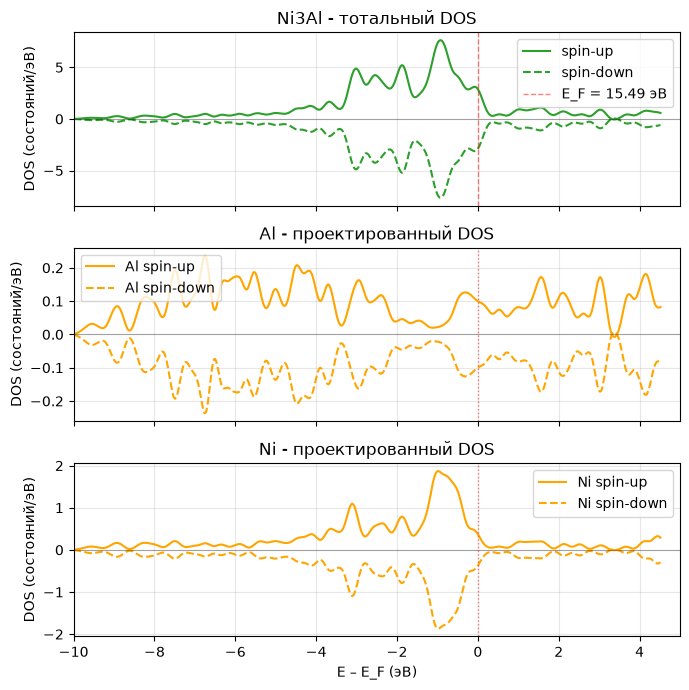

In [142]:
# Сдвиг энергии относительно уровня Ферми
e_total = Ni3Al_total_DOS_energy - Ni3Al_Fermi_energy
e_al = Ni3Al_pdos_Al['energy'] - Ni3Al_Fermi_energy
e_ni = Ni3Al_pdos_Ni['energy'] - Ni3Al_Fermi_energy

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# Ni3Al
axes[0].plot(e_total, dens_up_total, '-', label='spin-up', color='tab:green', linewidth=1.5)
axes[0].plot(e_total, -dens_down_total, '--', label='spin-down', color='tab:green', linewidth=1.5)
axes[0].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[0].axvline(0, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F = {Ni3Al_Fermi_energy:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Ni3Al - тотальный DOS')
axes[0].grid(alpha=0.3)
axes[0].legend()

# Al
axes[1].plot(e_al, dens_up_Al, '-', label='Al spin-up', color='orange', linewidth=1.5)
axes[1].plot(e_al, -dens_down_Al, '--', label='Al spin-down', color='orange', linewidth=1.5)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Al - проектированный DOS')
axes[1].grid(alpha=0.3)
axes[1].legend()

# Ni
axes[2].plot(e_ni, dens_up_Ni, '-', label='Ni spin-up', color='orange', linewidth=1.5)
axes[2].plot(e_ni, -dens_down_Ni, '--', label='Ni spin-down', color='orange', linewidth=1.5)
axes[2].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[2].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('E – E_F (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Ni - проектированный DOS')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.xlim(-10, 5)
plt.tight_layout()
plt.show()

# Сравнение QE vs VASP run_03

In [138]:
# Полные энергии из VASP run_03
TOTEN_Ni_03 = Ni_03_Outcar.final_energy
TOTEN_Al_03 = Al_03_Outcar.final_energy
TOTEN_Ni3Al_03 = Ni3Al_03_Outcar.final_energy

# Магнитные моменты из VASP run_03
Ni_mag_03 = Ni_03_Outcar.total_mag
Al_mag_03 = Al_03_Outcar.total_mag   # будет None
Ni3Al_mag_03 = Ni3Al_03_Outcar.total_mag

# Энергия образования из VASP run_03
dH_form_03_ev_per_fu = TOTEN_Ni3Al_03 - (0.75*TOTEN_Ni_03 + 0.25*TOTEN_Al_03)
dH_form_03_kJ_per_mol_atom = dH_form_03_ev_per_fu * 96.485 / 4

In [139]:
comparison_data = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'E (QE) (эВ)': [TOTEN_Ni, TOTEN_Al, TOTEN_Ni3Al],
    'E (VASP) (эВ)': [TOTEN_Ni_03, TOTEN_Al_03, TOTEN_Ni3Al_03],
    'ΔH_обр (QE) (кДж/моль ат.)': [None, None, dH_form_kJ_per_mol_atom],
    'ΔH_обр (VASP) (кДж/моль ат.)': [None, None, dH_form_03_kJ_per_mol_atom],
    'E_F (QE) (эВ)': [Ni_Fermi_energy, Al_Fermi_energy, Ni3Al_Fermi_energy],
    'E_F (VASP) (эВ)': [Ni_efermi_03, Al_efermi_03, Ni3Al_efermi_03],
    'a QE (Å)': [Ni_a, Al_a, Ni3Al_a],
    'a VASP (Å)': [Ni_a_03, Al_a_03, Ni3Al_a_03],
    'Магн. момент (QE)': [Ni_total_mag, Al_total_mag, Ni3Al_total_mag],
    'Магн. момент (VASP)': [Ni_mag_03, Al_mag_03, Ni3Al_mag_03],
}
df_compare = pd.DataFrame(comparison_data)
df_compare

,Система,E (QE) (эВ),E (VASP) (эВ),ΔH_обр (QE) (кДж/моль ат.),ΔH_обр (VASP) (кДж/моль ат.),E_F (QE) (эВ),E_F (VASP) (эВ),a QE (Å),a VASP (Å),Магн. момент (QE),Магн. момент (VASP)
0,Ni,-23355.946403,-22.289593,NaN,NaN,17.948364,4.773000,3.519999,3.520000,2.468327,2.504001
1,Al,-2149.865754,-14.983981,NaN,NaN,7.966063,11.706700,4.049998,4.050000,0.000000,NaN
2,Ni3Al,-18056.125281,-22.196585,-40.982981,-41.811665,15.493570,6.062900,3.569999,3.570000,-0.000216,0.001199


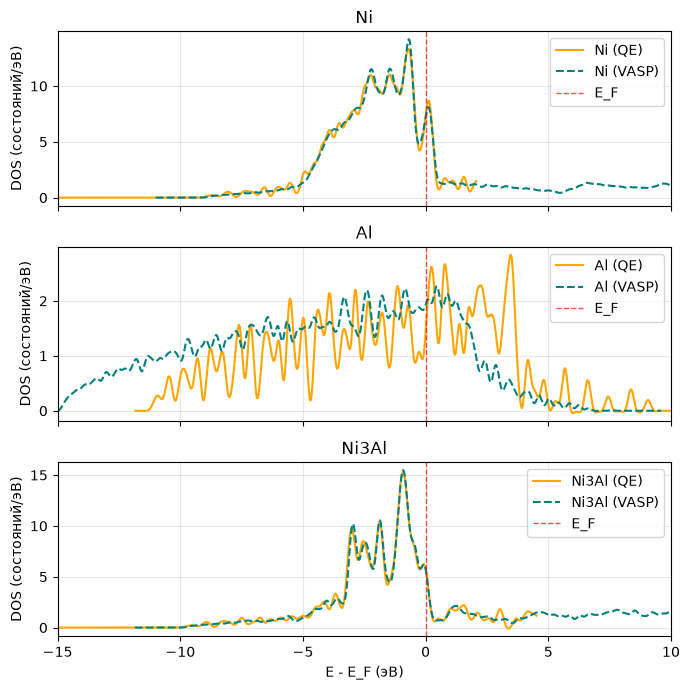

In [140]:
vasp_data = [
    (Ni_03_vasprun, Ni_efermi_03, 'Ni'),
    (Al_03_vasprun, Al_efermi_03, 'Al'),
    (Ni3Al_03_vasprun, Ni3Al_efermi_03, 'Ni3Al')
]

qe_data = [
    (Ni_total_DOS_energy, Ni_total_DOS_density, Ni_Fermi_energy, 'Ni'),
    (Al_total_DOS_energy, Al_total_DOS_density, Al_Fermi_energy, 'Al'),
    (Ni3Al_total_DOS_energy, Ni3Al_total_DOS_density, Ni3Al_Fermi_energy, 'Ni3Al')
]

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

for i, ((v03, ef03, label), (qe_e, qe_d, qef, _)) in enumerate(zip(vasp_data, qe_data)):
    dos03 = sum(v03.complete_dos.densities.values())
    e_qe = qe_e - qef
    e_vasp = v03.complete_dos.energies - ef03

    axes[i].plot(e_qe, qe_d, color='orange', label=f'{label} (QE)')
    axes[i].plot(e_vasp, dos03, color='teal', linestyle='--', label=f'{label} (VASP)')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=1, label='E_F')
    axes[i].set_ylabel('DOS (состояний/эВ)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_title(label)

axes[2].set_xlabel('E - E_F (эВ)')

plt.xlim(-15, 10)
plt.tight_layout()
plt.show()